# Gruppo 2613
- Giacomo Bregolin 2188429
- Leonardo Fardin
- Lara Fogarolo 2199475
- Francesco Peron 2185610

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow.random as tf_r

import keras
import tensorflow as tf
from keras.models import Sequential
from keras.layers import Dense, Dropout, Flatten #, Reshape
from keras.layers import Conv1D, MaxPooling1D, AveragePooling1D
plt.rcParams['font.size'] = 14

np.random.seed(12345)
tf_r.set_seed(12345)

2026-03-19 14:18:40.205126: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-03-19 14:18:40.227509: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-19 14:18:40.767207: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-03-19 14:18:44.760979: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off,

# Point 1

## Generate data

We want to study how the perfomance of the CNN, measured through accuracy, varies changing the amplitude of the pattern A while keeping DX fixed. We choose to use the same type of data generated during the lesson.

In [4]:
jump = lambda drift, stdev: int(np.random.normal(drift,stdev))

def pattern(i,z,a):
    return int(a*np.sin((np.pi*i)/z))

Z=12

N=10000
L=60

DX = 50 
bias = 5  

In [15]:
# RUN ONLY TO CREATE NEW DATA
'''
for A in range(100,800,50):
    y = [0] * N 
    x = [[0] * L for i in range(N)] 
    
    for i in range(N):
       
        if i>0: 
            x[i][0] = x[i-1][-1] + jump(bias,DX) 
        
        for j in range(1,L):
            x[i][j] = x[i][j-1] + jump(bias,DX) 
            
        y[i] = i%3 
    
        if y[i]>0:
            j0 = np.random.randint(0,L-1-Z) 
            sign = 3-2*y[i] 
            for j in range(Z): 
                x[i][j0+j] += sign*pattern(j,Z,A) 

    str0 = f'ts_L{L}_Z{Z}_A{A}_DX{DX}_bias{bias}_N{N}.dat'

    fname='DATA/x_'+str0
    np.savetxt(fname,x,fmt="%d")
    fname='DATA/y_'+str0
    np.savetxt(fname,y,fmt="%d")
'''

## CNN

We choose to use as CNN the first model used during the lesson.

In [11]:
input_shape = (L, 1)
n_class = 3 
                
reg = tf.keras.regularizers.l2(0.2)
ini = tf.keras.initializers.RandomNormal(mean=0.0, stddev=0.05, 
                                        seed=None)
NF = 5 
model = Sequential()
model.add(Conv1D(filters=NF, kernel_size=11, 
                     kernel_initializer=ini, 
                     kernel_regularizer=reg,
                     activation='relu', 
                     input_shape=input_shape))
model.add(AveragePooling1D(5))
model.add(Conv1D(filters=5, kernel_size=7, 
                 activation='relu'))
model.add(Flatten())
model.add(Dense(12, activation='relu'))
model.add(Dropout(0.2))

model.add(Dense(n_class, activation='softmax')) # softmax !

print(model.summary())

opt = tf.keras.optimizers.Adam()

# compile the model
model.compile(loss=keras.losses.categorical_crossentropy,
              optimizer=opt,metrics=['accuracy'])



Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_2 (Conv1D)               │ (None, 50, 5)          │            60 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling1d_1             │ (None, 10, 5)          │             0 │
│ (AveragePooling1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 4, 5)           │           180 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 20)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 12)             │           252 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 12)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │            39 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 531 (2.07 KB)

 Trainable params: 531 (2.07 KB)

 Non-trainable params: 0 (0.00 B)

None


In [12]:
# TRAINING OF THE CNN OVER DIFFERENT DATASETS
'''
BATCH_SIZE = 200
EPOCHS = 150
best_acc = 0
j = 0
models = []
acc = []

for A in range(100,800,50):
    str0 = f'ts_L{L}_Z{Z}_A{A}_DX{DX}_bias{bias}_N{N}.dat'
    fnamex='DATA/x_'+str0
    fnamey='DATA/y_'+str0
    
    x = np.loadtxt(fnamex, delimiter=" ",dtype=float)
    
    N,L = len(x), len(x[0])

    categ = np.loadtxt(fnamey, dtype=int)  
    
    y = np.zeros((N,n_class))
    for i in range(N):
        y[i][categ[i]] = 1. # y contains one-hot encoding


    # split into training and validation sets
    perc_train=0.8
    N_train = int(perc_train*N)
    x_train = x[:N_train]
    
    y_train = y[:N_train]
    x_val = x[N_train:]
    y_val = y[N_train:]
    N_val = len(x_val)
    
     
    #remove average value of each sample from its values
    xm_train = x_train.mean(axis=1)
    std_train = x_train.std(axis=1)
    xm_val = x_val.mean(axis=1)
    std_val = x_val.std(axis=1)
    
    # rescale with variance on the training set
    for i in range(N_train):
         x_train[i] = (x_train[i]-xm_train[i])/ std_train.mean(axis=0)
    for i in range(N_val):
        x_val[i] = (x_val[i]-xm_val[i])/ std_val.mean(axis=0)
    
    x_train = x_train.reshape(x_train.shape[0], L, 1)
    x_val =  x_val.reshape(x_val.shape[0], L, 1)

    fit = model.fit(x_train,y_train,batch_size=BATCH_SIZE,
                epochs=EPOCHS,
                validation_data=(x_val, y_val),
                verbose=0, shuffle=True) 
    
    models.append(fit)    
    acc.append(fit.history['val_accuracy'][-1])
    
    if fit.history['val_accuracy'][-1] > best_acc:
        best_acc = fit.history['val_accuracy'][-1]
        best_model = fit
        best_A = A

    print(f"Training dataset: {j}")
    j+=1

'''

Training dataset: 0
Training dataset: 1
Training dataset: 2
Training dataset: 3
Training dataset: 4
Training dataset: 5
Training dataset: 6
Training dataset: 7
Training dataset: 8
Training dataset: 9
Training dataset: 10
Training dataset: 11
Training dataset: 12
Training dataset: 13


In [17]:
print("Amplitude that determines the best performance of the CNN: ", best_A)

Amplitude that determines the best performance of the CNN:  750


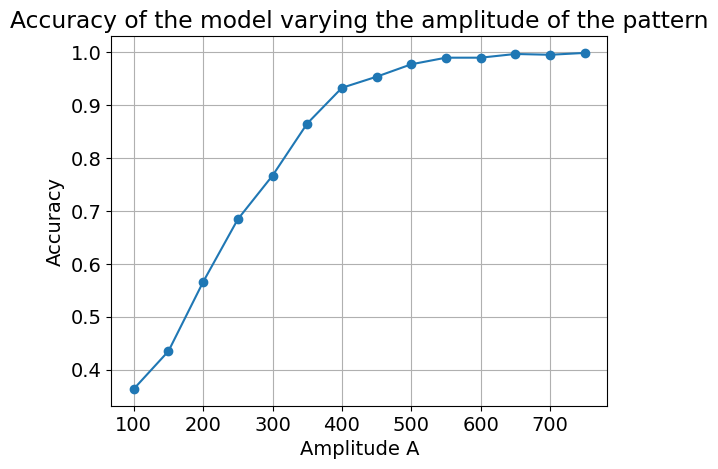

In [25]:
plt.plot(np.arange(100, 800, 50), acc, marker='o')
plt.xlabel("Amplitude A")
plt.ylabel("Accuracy")
plt.title("Accuracy of the model varying the amplitude of the pattern")
plt.grid()
plt.show()

As we expect, the accuracy of the model is better for greater values of A.